
# Task 1 

1 .Load anyone dataset and do all types of Data Visualization along with Insights and submit the presentation in PPT format.

## Step 1: Dataset selection

In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

passenger_data = sns.load_dataset("titanic")
passenger_data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


## Step2: Data Cleaning

In [3]:
print("Shape: ", passenger_data.shape)

Shape:  (891, 15)


In [4]:
print("Columns List: ", passenger_data.columns)

Columns List:  Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')


In [5]:
print("Datatypes: ", passenger_data.dtypes)

Datatypes:  survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object


In [6]:
print("Info: ", passenger_data.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
Info:  None


In [7]:
print("Describe: \n", passenger_data.describe())

Describe: 
          survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


In [8]:
print("Check Missing Values: \n", passenger_data.isnull().sum())

Check Missing Values: 
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [9]:
print("Find Duplicate Values:", passenger_data.duplicated().sum())

Find Duplicate Values: 107


In [10]:
passenger_data.drop_duplicates(inplace=True)

In [11]:
(print("After Duplicate Values Removed Shape: ", passenger_data.shape))

After Duplicate Values Removed Shape:  (784, 15)


In [12]:
# Fill Missing Values 

passenger_data.age = passenger_data.age.fillna(passenger_data.age.median())
passenger_data.embarked = passenger_data.embarked.fillna(passenger_data.embarked.mode()[0])
passenger_data.embark_town = passenger_data.embark_town.fillna(passenger_data.embark_town.mode()[0])

In [13]:
# Delete Deck features in the dataset

del passenger_data["deck"]

In [14]:
print("Missing value count per feature after data cleaning:\n", passenger_data.isnull().sum())

Missing value count per feature after data cleaning:
 survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [15]:
# Create new Business Feature 


passenger_data["family_size"] = passenger_data["sibsp"] + passenger_data["parch"] + 1  # for family size
passenger_data["fare_per_person"] = passenger_data["fare"] / passenger_data["family_size"] # for fare per person
passenger_data["age_group"] = pd.cut(x = passenger_data.age, bins=[0,12,18,35,60,100], labels=["Child","Teen","Young Adult","Adult","Senior"])

passenger_data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,family_size,fare_per_person,age_group
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,2,3.62500,Young Adult
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,2,35.64165,Adult
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,1,7.92500,Young Adult
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,2,26.55000,Young Adult
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,1,8.05000,Young Adult


In [16]:
# Final Dataset Information

passenger_data.info()

<class 'pandas.DataFrame'>
Index: 784 entries, 0 to 890
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   survived         784 non-null    int64   
 1   pclass           784 non-null    int64   
 2   sex              784 non-null    str     
 3   age              784 non-null    float64 
 4   sibsp            784 non-null    int64   
 5   parch            784 non-null    int64   
 6   fare             784 non-null    float64 
 7   embarked         784 non-null    str     
 8   class            784 non-null    category
 9   who              784 non-null    str     
 10  adult_male       784 non-null    bool    
 11  embark_town      784 non-null    str     
 12  alive            784 non-null    str     
 13  alone            784 non-null    bool    
 14  family_size      784 non-null    int64   
 15  fare_per_person  784 non-null    float64 
 16  age_group        784 non-null    category
dtypes: bool(2), c

## Step 3: Univirate Analysis

* Univariate Analysis means analyzing one variable (one feature) at a time.

#### Visualization 1: Count Plot – Passenger Survival

* Count plot x axis must discrete data
* discreate means countable , cannot measurable and not segregated
* continuous means cannot count, it has measurale and it can  segregated

In [17]:
passenger_data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,family_size,fare_per_person,age_group
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,2,3.62500,Young Adult
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,2,35.64165,Adult
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,1,7.92500,Young Adult
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,2,26.55000,Young Adult
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,1,8.05000,Young Adult


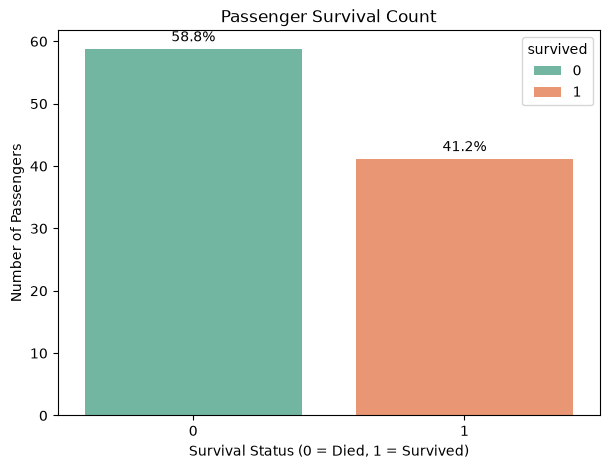

In [18]:
plt.figure(figsize= (7, 5))
ax = sns.countplot(data = passenger_data, x="survived", hue="survived", palette="Set2", stat="percent")
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.title("Passenger Survival Count")
plt.xlabel("Survival Status (0 = Died, 1 = Survived)")
plt.ylabel("Number of Passengers")
plt.show()

#### Visualization 2: Count Plot – Passenger Class


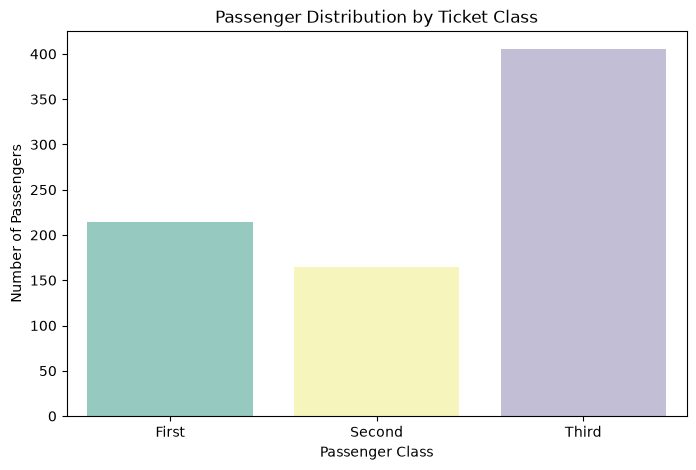

In [19]:
plt.figure(figsize= (8, 5))
sns.countplot(data = passenger_data, x="class", hue="class", palette="Set3", legend=False, dodge=False,)

plt.title("Passenger Distribution by Ticket Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()

#### Visualization 3: Histogram – Passenger Age Distribution

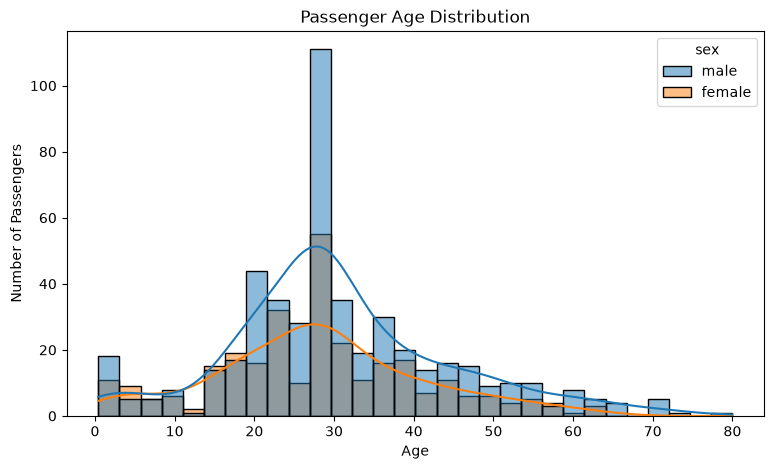

In [20]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=passenger_data,
    x="age",
    hue="sex",
    bins=30,
    kde=True,
    color="green",
    multiple="layer"
)

plt.title("Passenger Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

## Step 4: Bivariate Analysis

* Bivariate Analysis is the process of studying the relationship between two variables. It helps us understand how one variable influences or is associated with another.

#### Visualization 1: Bar Plot – Passenger Class vs Survival Rate

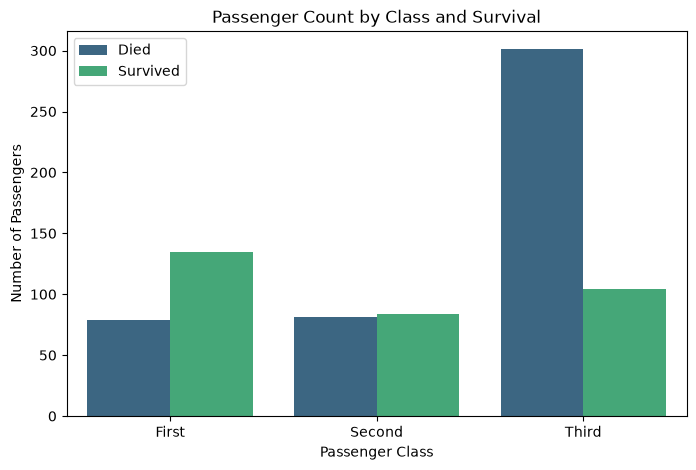

In [26]:
plt.figure(figsize=(8,5))
sns.countplot(
    x="class", 
    hue="survived", 
    data=passenger_data, 
    order=["First", "Second", "Third"], 
    palette="viridis"
)
plt.title("Passenger Count by Class and Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(["Died", "Survived"])
plt.show()


#### Visualization 2: Count Plot – Gender vs Survival

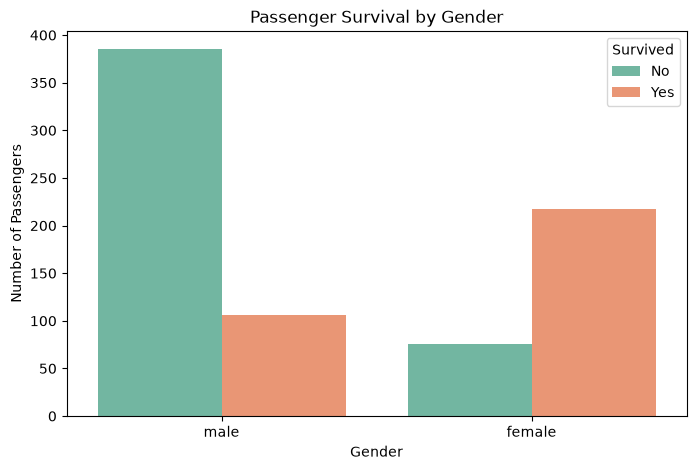

In [32]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="sex",
    hue="survived",
    data=passenger_data,
    palette="Set2"
)

plt.title("Passenger Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.legend(title="Survived", labels=["No", "Yes"])

plt.show()

#### Visualization 3: Scatter Plot – Age vs Fare (Colored by Survival)

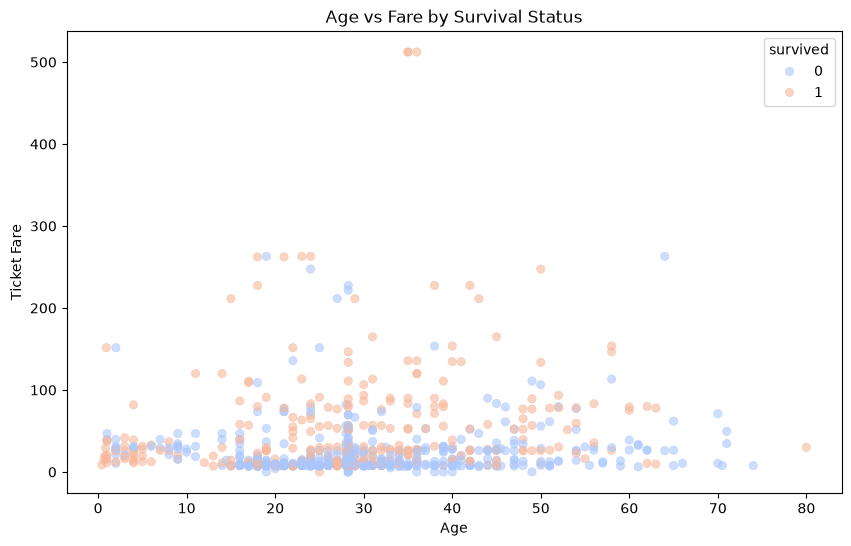

In [41]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="age", 
    y="fare", 
    hue="survived", 
    data=passenger_data, 
    palette="coolwarm",
    alpha=0.6, 
    edgecolor=None 
)
plt.title("Age vs Fare by Survival Status")
plt.xlabel("Age")
plt.ylabel("Ticket Fare")
plt.show()


## Part 5 – Multivariate Analysis
   * Multivariate Analysis is the process of analyzing three or more variables simultaneously to understand complex relationships that cannot be seen by comparing only two variables.

#### Visualization 1: Correlation Heatmap

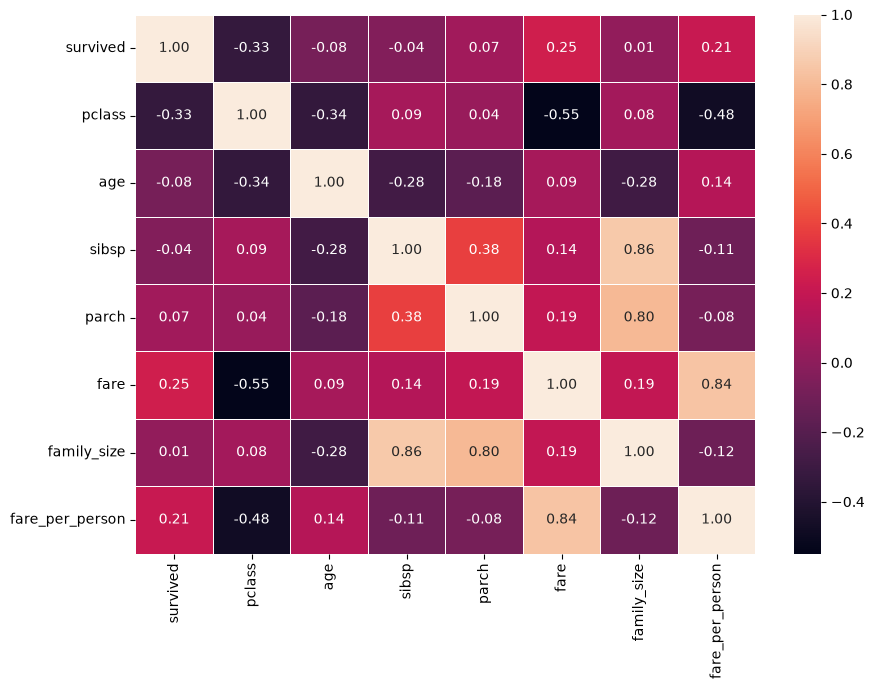

In [48]:
plt.figure(figsize=(10, 7))

corr_matrix = passenger_data.select_dtypes(include=['number']).corr()
sns.heatmap(
    corr_matrix,
     annot=True,
     linewidths=0.5,
     fmt=".2f"
)
plt.show()

#### Visualization 2: Pivot Table Heatmap – Survival Rate by Age Group and Passenger Class

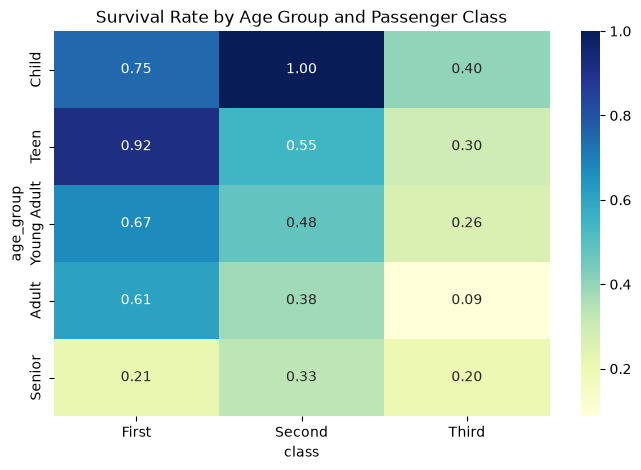

In [54]:
pivot = passenger_data.pivot_table(
    values="survived",
    index="age_group",
    columns="class",
    aggfunc="mean"
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    data = pivot,
    annot= True,
    cmap="YlGnBu",
    fmt=".2f"
)
plt.title("Survival Rate by Age Group and Passenger Class")

plt.show()
